# IDS Project — Notebook 2: Model Training
**Models:** XGBoost (GPU) + LSTM (PyTorch CUDA)  
**Hardware:** i9-13950HX + RTX 3500 Ada  
> Run Notebook 1 first to generate the `.npy` and `.pkl` files.

## 0. CUDA Diagnostic (run this first)

In [1]:
import sys, subprocess
print(f'Python: {sys.version}')

# Check CUDA driver without crashing
try:
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,driver_version,memory.total',
                             '--format=csv,noheader'], capture_output=True, text=True, timeout=5)
    print(f'GPU info: {result.stdout.strip()}')
except Exception as e:
    print(f'nvidia-smi failed: {e}')

# Check installed torch CUDA build tag
try:
    import torch
    print(f'PyTorch: {torch.__version__}')
    print(f'CUDA build: {torch.version.cuda}')
    print(f'CUDA available: {torch.cuda.is_available()}')
    if torch.cuda.is_available():
        print(f'GPU: {torch.cuda.get_device_name(0)}')
        print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    else:
        print('WARNING: CUDA not available — LSTM will train on CPU (slower).')
        print('To fix: pip install torch --index-url https://download.pytorch.org/whl/cu121')
    TORCH_OK = True
except Exception as e:
    print(f'PyTorch import error: {e}')
    TORCH_OK = False

Python: 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:16:45) [MSC v.1942 64 bit (AMD64)]
GPU info: NVIDIA RTX 3500 Ada Generation Laptop GPU, 595.97, 12282 MiB
PyTorch: 2.11.0+cu126
CUDA build: 12.6
CUDA available: True
GPU: NVIDIA RTX 3500 Ada Generation Laptop GPU
VRAM: 12.9 GB


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
print(f'XGBoost: {xgb.__version__}')

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Device setup ──────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
XGB_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch device : {DEVICE}')
print(f'XGBoost device : {XGB_DEVICE}')

XGBoost: 3.2.0
PyTorch device : cuda
XGBoost device : cuda


## 2. Load Preprocessed Data

In [3]:
X_train   = np.load('X_train.npy')
X_test    = np.load('X_test.npy')
y_train_b = np.load('y_train_binary.npy')
y_test_b  = np.load('y_test_binary.npy')
y_train_m = np.load('y_train_multi.npy')
y_test_m  = np.load('y_test_multi.npy')

with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
with open('selected_features.pkl', 'rb') as f:
    selected_features = pickle.load(f)

n_classes = len(np.unique(y_train_m))
print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Classes : {n_classes}  |  Features : {len(selected_features)}')

Train : (2262300, 30)  |  Test : (565576, 30)
Classes : 15  |  Features : 30


---
# Part A — XGBoost (GPU Accelerated)

## 3A. Binary Classification (Attack / Normal)

In [4]:
xgb_binary = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    device=XGB_DEVICE,
    random_state=42,
    early_stopping_rounds=20,
    verbosity=1
)

xgb_binary.fit(
    X_train, y_train_b,
    eval_set=[(X_test, y_test_b)],
    verbose=50
)
print('Binary XGBoost done.')

[0]	validation_0-logloss:0.40472
[50]	validation_0-logloss:0.00850
[100]	validation_0-logloss:0.00500
[150]	validation_0-logloss:0.00389
[200]	validation_0-logloss:0.00353
[250]	validation_0-logloss:0.00338
[300]	validation_0-logloss:0.00333
[350]	validation_0-logloss:0.00330
[385]	validation_0-logloss:0.00330
Binary XGBoost done.


In [5]:
y_pred_b = xgb_binary.predict(X_test)
y_prob_b = xgb_binary.predict_proba(X_test)[:, 1]

print('=== Binary Classification Report ===')
print(classification_report(y_test_b, y_pred_b, target_names=['BENIGN', 'ATTACK']))
print(f'ROC-AUC: {roc_auc_score(y_test_b, y_prob_b):.4f}')

=== Binary Classification Report ===
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    454265
      ATTACK       1.00      1.00      1.00    111311

    accuracy                           1.00    565576
   macro avg       1.00      1.00      1.00    565576
weighted avg       1.00      1.00      1.00    565576

ROC-AUC: 1.0000


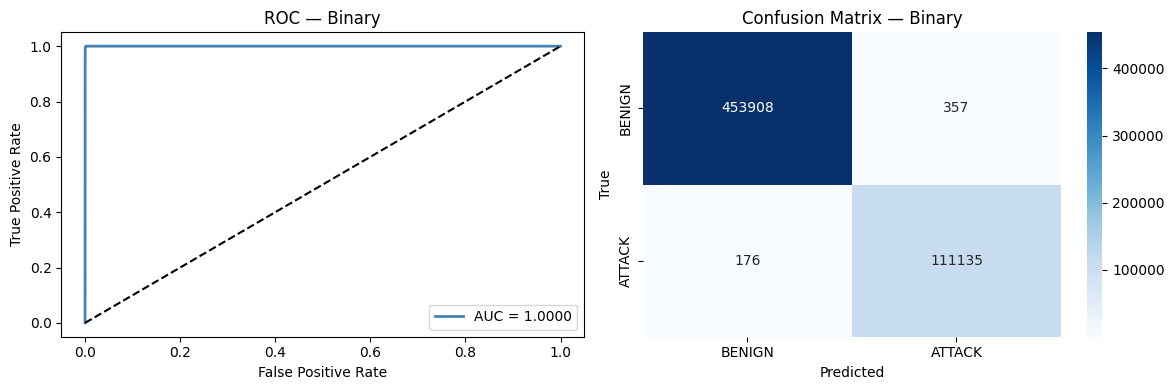

In [6]:
fpr, tpr, _ = roc_curve(y_test_b, y_prob_b)
auc = roc_auc_score(y_test_b, y_prob_b)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC — Binary')
axes[0].legend()

cm = confusion_matrix(y_test_b, y_pred_b)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['BENIGN','ATTACK'], yticklabels=['BENIGN','ATTACK'])
axes[1].set_title('Confusion Matrix — Binary')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('xgb_binary_eval.png', dpi=150)
plt.show()

## 4A. Multi-Class Classification (Attack Type)

In [7]:
xgb_multi = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=n_classes,
    eval_metric='mlogloss',
    device=XGB_DEVICE,
    random_state=42,
    early_stopping_rounds=20,
    verbosity=1
)

xgb_multi.fit(
    X_train, y_train_m,
    eval_set=[(X_test, y_test_m)],
    verbose=50
)
print('Multi-class XGBoost done.')

[0]	validation_0-mlogloss:0.52098
[50]	validation_0-mlogloss:0.00761
[100]	validation_0-mlogloss:0.00438
[150]	validation_0-mlogloss:0.00411
[200]	validation_0-mlogloss:0.00406
[250]	validation_0-mlogloss:0.00405
Multi-class XGBoost done.


In [8]:
y_pred_m = xgb_multi.predict(X_test)
print('=== Multi-Class Classification Report ===')
print(classification_report(y_test_m, y_pred_m, target_names=le.classes_))

=== Multi-Class Classification Report ===
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    454265
                       Bot       0.93      0.75      0.83       376
                      DDoS       1.00      1.00      1.00     25301
             DoS GoldenEye       1.00      1.00      1.00      2098
                  DoS Hulk       1.00      1.00      1.00     46258
          DoS Slowhttptest       0.99      0.99      0.99      1083
             DoS slowloris       0.99      1.00      0.99      1128
               FTP-Patator       1.00      1.00      1.00      1595
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.75      0.60      0.67         5
                  PortScan       0.99      1.00      1.00     31835
               SSH-Patator       1.00      1.00      1.00      1211
  Web Attack � Brute Force       0.67      0.73      0.70       290
Web A

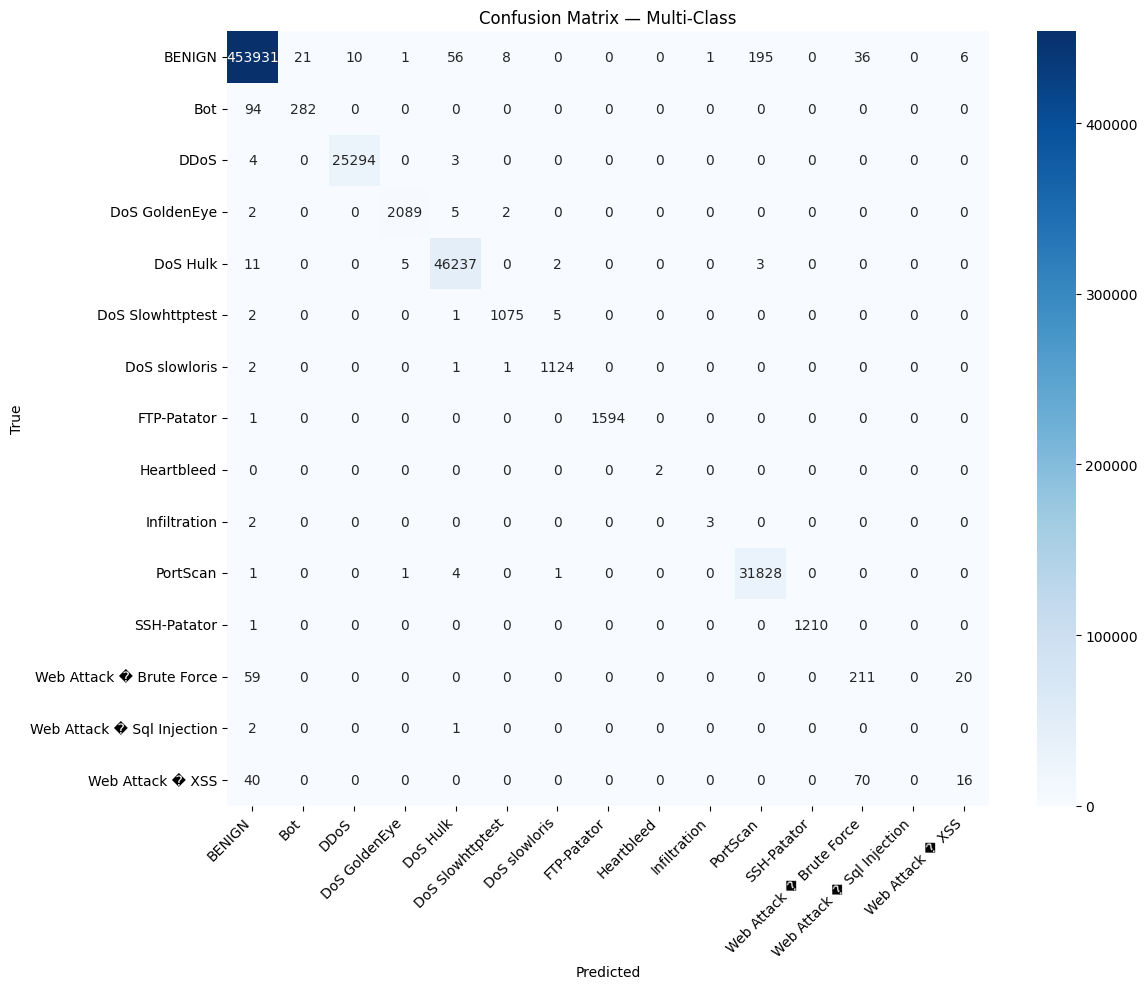

In [9]:
cm_m = confusion_matrix(y_test_m, y_pred_m)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Multi-Class')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cm_multiclass.png', dpi=150)
plt.show()

## 5A. Save XGBoost Models

In [10]:
xgb_binary.save_model('xgb_binary.json')
xgb_multi.save_model('xgb_multi.json')
print('Saved: xgb_binary.json, xgb_multi.json')

Saved: xgb_binary.json, xgb_multi.json


---
# Part B — LSTM (PyTorch + CUDA)
> If CUDA diagnostic in Cell 0 showed errors, LSTM will still run on CPU.

## 3B. Prepare Data for LSTM

In [11]:
print(f'Training LSTM on: {DEVICE}')

X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)  # (N, 1, F)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train_b, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_b,  dtype=torch.float32)

BATCH_SIZE = 4096
# num_workers=0 required on Windows — multiprocessing fork not supported
PIN = DEVICE.type == 'cuda'

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=PIN
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=PIN
)

print(f'Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}')

Training LSTM on: cuda
Train batches: 553  |  Test batches: 139


## 4B. Define LSTM Model

In [12]:
class IDSNet(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.classifier(out[:, -1, :]).squeeze(1)


n_features = X_train.shape[1]
model = IDSNet(input_size=n_features).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}  |  Device: {next(model.parameters()).device}')

Parameters: 222,337  |  Device: cuda:0


## 5B. Train LSTM

In [13]:
pos_weight = torch.tensor(
    [(y_train_b == 0).sum() / max((y_train_b == 1).sum(), 1)],
    dtype=torch.float32
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)

EPOCHS = 20
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(y_b)
    train_loss = running_loss / len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_b, y_b in test_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            val_loss += criterion(model(X_b), y_b).item() * len(y_b)
    val_loss /= len(test_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:02d}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {lr_now:.2e}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'lstm_best.pt')

print('\nDone. Best model → lstm_best.pt')

Epoch 01/20 | Train: 0.3527 | Val: 0.2297 | LR: 1.00e-03
Epoch 02/20 | Train: 0.2233 | Val: 0.1975 | LR: 1.00e-03
Epoch 03/20 | Train: 0.1965 | Val: 0.1713 | LR: 1.00e-03
Epoch 04/20 | Train: 0.1726 | Val: 0.1483 | LR: 1.00e-03
Epoch 05/20 | Train: 0.1566 | Val: 0.1384 | LR: 1.00e-03
Epoch 06/20 | Train: 0.1449 | Val: 0.1299 | LR: 1.00e-03
Epoch 07/20 | Train: 0.1344 | Val: 0.1161 | LR: 1.00e-03
Epoch 08/20 | Train: 0.1253 | Val: 0.1137 | LR: 1.00e-03
Epoch 09/20 | Train: 0.1187 | Val: 0.1224 | LR: 1.00e-03
Epoch 10/20 | Train: 0.1125 | Val: 0.0970 | LR: 1.00e-03
Epoch 11/20 | Train: 0.1072 | Val: 0.1034 | LR: 1.00e-03
Epoch 12/20 | Train: 0.1039 | Val: 0.0932 | LR: 1.00e-03
Epoch 13/20 | Train: 0.1005 | Val: 0.0853 | LR: 1.00e-03
Epoch 14/20 | Train: 0.0975 | Val: 0.0836 | LR: 1.00e-03
Epoch 15/20 | Train: 0.0950 | Val: 0.0829 | LR: 1.00e-03
Epoch 16/20 | Train: 0.0947 | Val: 0.1037 | LR: 1.00e-03
Epoch 17/20 | Train: 0.0905 | Val: 0.0816 | LR: 1.00e-03
Epoch 18/20 | Train: 0.0900 | V

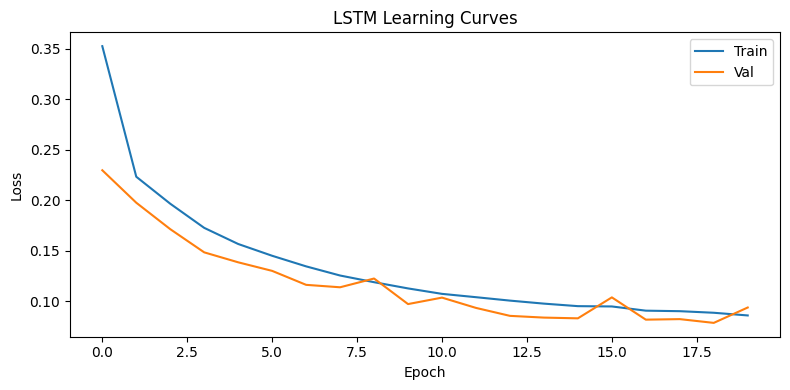

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Learning Curves')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_learning_curves.png', dpi=150)
plt.show()

## 6B. Evaluate LSTM

In [15]:
model.load_state_dict(torch.load('lstm_best.pt', map_location=DEVICE, weights_only=True))
model.eval()

all_logits, all_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        all_logits.append(model(X_b.to(DEVICE)).cpu())
        all_labels.append(y_b)

all_logits = torch.cat(all_logits).numpy()
all_labels = torch.cat(all_labels).numpy()
lstm_probs = torch.sigmoid(torch.tensor(all_logits)).numpy()
lstm_preds = (lstm_probs >= 0.5).astype(int)

print('=== LSTM Binary Classification Report ===')
print(classification_report(all_labels, lstm_preds, target_names=['BENIGN', 'ATTACK']))
print(f'ROC-AUC: {roc_auc_score(all_labels, lstm_probs):.4f}')

=== LSTM Binary Classification Report ===
              precision    recall  f1-score   support

      BENIGN       1.00      0.97      0.98    454265
      ATTACK       0.89      0.99      0.94    111311

    accuracy                           0.98    565576
   macro avg       0.95      0.98      0.96    565576
weighted avg       0.98      0.98      0.98    565576

ROC-AUC: 0.9982


---
# Part C — Model Comparison

In [16]:
models_results = {
    'XGBoost': {'preds': y_pred_b,  'probs': y_prob_b,   'labels': y_test_b},
    'LSTM':    {'preds': lstm_preds, 'probs': lstm_probs, 'labels': all_labels},
}

summary = []
for name, res in models_results.items():
    summary.append({
        'Model':     name,
        'Accuracy':  accuracy_score(res['labels'],  res['preds']),
        'Precision': precision_score(res['labels'], res['preds']),
        'Recall':    recall_score(res['labels'],    res['preds']),
        'F1':        f1_score(res['labels'],        res['preds']),
        'ROC-AUC':   roc_auc_score(res['labels'],   res['probs']),
    })

summary_df = pd.DataFrame(summary).set_index('Model')
print(summary_df.to_string(float_format='{:.4f}'.format))

         Accuracy  Precision  Recall     F1  ROC-AUC
Model                                               
XGBoost    0.9991     0.9968  0.9984 0.9976   1.0000
LSTM       0.9751     0.8921  0.9936 0.9401   0.9982


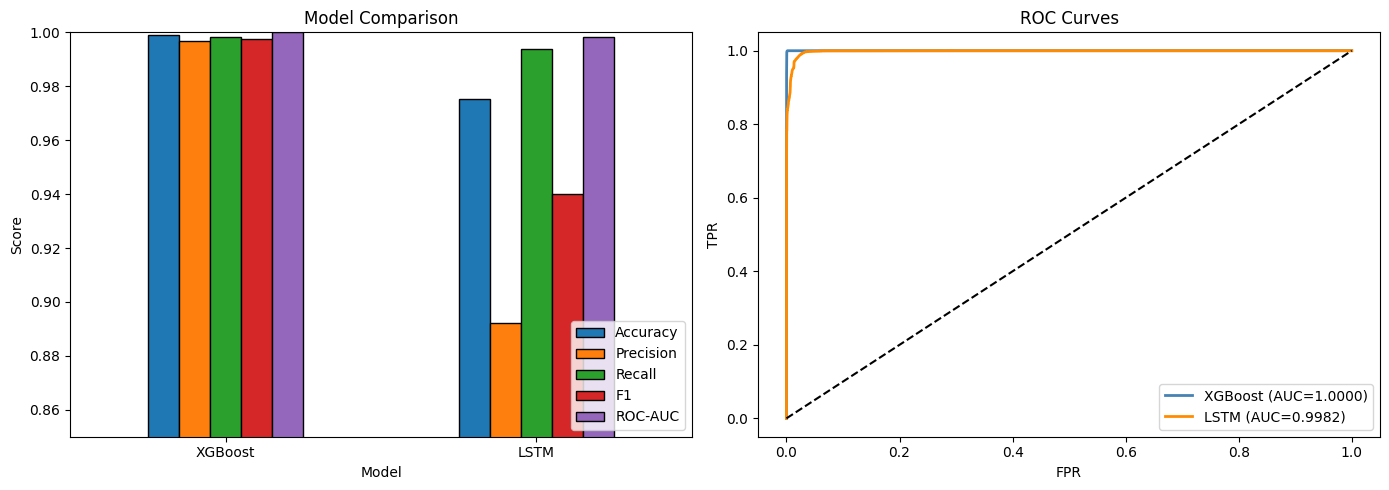

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar comparison
summary_df.plot(kind='bar', ax=axes[0], edgecolor='black', ylim=(0.85, 1.0))
axes[0].set_title('Model Comparison')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(loc='lower right')

# Overlay ROC
colors = ['steelblue', 'darkorange']
for (name, res), color in zip(models_results.items(), colors):
    fpr, tpr, _ = roc_curve(res['labels'], res['probs'])
    auc = roc_auc_score(res['labels'], res['probs'])
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, lw=2)
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curves')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## Summary

| File | Description |
|------|-------------|
| `xgb_binary.json` | XGBoost binary detector |
| `xgb_multi.json` | XGBoost multi-class attack classifier |
| `lstm_best.pt` | Best LSTM checkpoint |

**Next:** Notebook 3 — Real-Time Detection